# <font style="color:blue">Table of Content</font>

- [Step 1: Understand Your Problem](#step1)
- [Step 2: Get the Data](#step2)
- [Step 3. Data Preparation](#step3)
- [Step 4: Train a Simple Model](#step4)
- [Step 5: Sample Prediction](#step5)
- [Step 6. Display Mistakes](#step6)

# <font style="color:blue">Project 1 - Part 2: Train an Image Classifier From Scratch</font>
As discussed in the previous notebook, the steps for training Neural Networks are:

- Step 1 - Understand your problem
- Step 2A - Get the data
- Step 2B - Explore and understand your data
- Step 2C - Create a sample data from the dataset
- Step 3 - Data preparation
- Step 4 - Train a simple model on sample data and check the pipeline before proceeding to train the full network
- Step 5 - Train on full data
- Step 6 - Improve your model

You have already been through Steps `1-4` in the previous notebook. Use them here as well.

Here, you will implement Steps `5` & `6` from scratch. Design a model that achieves `>=85%` validation accuracy on the given dataset.

There are 70 points for this notebook. The sections which carry marks are in Red.

There are **70 points** for this notebook. <font style="color:red">The sections which carry marks are in Red.</font>

For GPU compute you can use Kaggle Kernels, Google Colab or any other service of your choice.

After completing the assignment, upload and submit it on the portal for feedback.

<font style="color:red">Use the full data to train the network. You need to achieve 85% accuracy for validation data to successfully complete this assignment.</font>


<font style="color:red">Just remember to build your own model, not use any pre-trained models/weights.</font>


Upon completing the assignment, <font style="color:red">upload the notebook and the models folder on the portal for  feedback.</font>

## <font style="color:blue">3.1. Import Libraries </font>

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:98% !important; }</style>"))
%load_ext autoreload  
%autoreload 2
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
%matplotlib inline

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [4]:
import os
import time

from typing import Iterable
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms

from torch.optim import lr_scheduler

In [5]:
import sys 
import gc
for p in ['../..']:
    if p not in sys.path:
        # print(f"insert {p}")
        sys.path.insert(0, p)
print(sys.path)

['../..', '/home/kbardool/miniconda3/envs/opencv/lib/python312.zip', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12/lib-dynload', '', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12/site-packages', '/tmp/tmpm63czgnv']


In [6]:
from training_code import *
from types import SimpleNamespace

In [7]:
os.environ["WANDB_NOTEBOOK_NAME"] = "Training_from_scratch.ipynb"

In [8]:
from torchinfo import summary
from models import *
summary_col_names = ("input_size",
            "output_size",
            "num_params",
            "params_percent",
            "kernel_size",
            "mult_adds",
            "trainable" )

# <font style="color:blue">Step 4: Train Your Model</font><a name="step4"></a>

Now, create the training pipeline, and train your model on the full data.

## <font style="color:red">4.8. Define Model [20 Points]</font>

Next, define the CNN model. Keep iterating. Do this by training various models. Just ,change the :
    
- number of layers
- parameters inside the layers
- different types of layers

In [9]:
from models_2 import *

In [10]:
# # del Model_v61 # model = Model_v031() 
model = Model_v81b() # MyModel = Model_v41
# model = Model_v061() # MyModel = Model_v41
# model = Model_v06() # MyModel = Model_v41
# model = Model_v07_Repl()
print(model)

Model_v81b(
  (body): Sequential(
    (0): Conv2d(3, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1,

In [11]:
# model = Model_v71c() # MyModel = Model_v41
input_size = (4, 3, 224, 224)
print(f"\n {model.name}")
print(summary(model.body, input_size = input_size, col_names=summary_col_names))
print(f"\n {model.name}")
ms = summary(model, input_size = input_size, col_names=summary_col_names)
print(ms)


 Model_v81b
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Param %                   Kernel Shape              Mult-Adds                 Trainable
Sequential                               [4, 3, 224, 224]          [4, 4096]                 --                             --                   --                        --                        True
├─Conv2d: 1-1                            [4, 3, 224, 224]          [4, 256, 224, 224]        19,456                      0.02%                   [5, 5]                    3,904,897,024             True
├─BatchNorm2d: 1-2                       [4, 256, 224, 224]        [4, 256, 224, 224]        512                         0.00%                   --                        2,048                     True
├─ReLU: 1-3                              [4, 256, 224, 224]        [4, 256, 224, 224]        --                             --                   --                        -- 

## <font style="color:red">4.9. Training [20 Points]</font>

Experiment with:

- Optimizers and learning rate schedulers \[You can  get good results even without a learning rate scheduler\]

- Regularization techniques like Data Augmentation, Dropout, BatchNorm

In [12]:
try:
    del model
    print('model')
    del metrics
    print('metrics')
    del optimizer, scheduler
    print('optimizer, scheduler')
    del train_config, sys_config
    print('train_config, sys_config')
    del train_loader, test_loader
    print('train_loader, test_loader')
except Exception as e:
    print(e)
    pass

model
name 'metrics' is not defined


In [13]:
MODEL_NAME = "Model_v81b"
BATCH_SIZE = 6
LEARNING_RATE = 1.0e-04
DROPOUT_RATE = 0.4
EPOCHS = 90
SUBSET_SIZE = 1.0
print('done')

done


In [14]:
try:
    del model
    print('model')
    del metrics
    print('metrics')
    del optimizer, scheduler
    print('optimizer, scheduler')
    del train_config, sys_config
    print('train_config, sys_config')
    del train_loader, test_loader
    print('train_loader, test_loader')
except Exception as e:
    print(e)
    pass

gc.collect()
torch.cuda.empty_cache()

MODEL = globals()[MODEL_NAME]
model = MODEL(p=DROPOUT_RATE)
init_model(model)
print(f"{model.name}")
print(model)

metrics = Metrics()
sys_config = SystemConfiguration()
train_config = TrainingConfiguration()

train_config.batch_size: int = BATCH_SIZE  # 10 
train_config.epochs_count: int = EPOCHS   # 50  
train_config.init_learning_rate: float = LEARNING_RATE  ## 0.1  # initial learning rate for lr scheduler 
train_config.model_name = MODEL_NAME
train_config.dropout_rate = DROPOUT_RATE
train_config.subset_size = SUBSET_SIZE

do = f"_p{train_config.dropout_rate:3.1f}" if train_config.dropout_rate != 0.0 else ""
train_config.run_name = f"{MODEL_NAME}_BS_{BATCH_SIZE:03d}_LR_{LEARNING_RATE:.1e}{do}_n"

print(sys_config)
print(train_config)

# data loader
train_loader, test_loader = get_data(batch_size=train_config.batch_size,
                                     data_root=train_config.data_root,
                                     num_workers=train_config.num_workers,
                                     data_augmentation=True,
                                     subset_size=train_config.subset_size
                                     )

# optimizer
optimizer = optim.Adam(model.parameters(),
                       lr = train_config.init_learning_rate
                      )

scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, 
                                                  patience=10, cooldown=5, 
                                                  threshold=0.00001, threshold_mode='rel', 
                                                  min_lr=0, eps=1e-08)

wandb_data = {'project_name': 'OpenCV_Pytorch',
              'exp_id' : None,
              'exp_name': train_config.run_name,
              'exp_description': train_config.run_name
             }

print(f" wandb data        : {wandb_data}\n\n")

print(f" Model name        : {train_config.model_name}   \n"
      f" epochs            : {train_config.epochs_count} \n"
      f" Batch size        : {train_config.batch_size}   \n"
      f" Initial LR        : {train_config.init_learning_rate} \n"
      f" Data Subset Ratio : {train_config.subset_size}   \n"
      f" Dropout rate      : {train_config.dropout_rate}  \n"
      f" Current LR        : {optimizer.param_groups[0]['lr']:.2e}   {scheduler.get_last_lr()[0]:.2e} \n"
      f" Scheduler Best    : {scheduler.best:f}   {scheduler} \n\n"
      f" Run Name          : {train_config.run_name}")
      # f" last epoch  : {epochs_count}        Next run - from epoch {beginning_epoch} to {ending_epoch-1}\n\n"
      # f" Best loss   : {best_loss:.4f}    Best Accuracy: {best_accuracy:.4f} \n\n"
      # f" len train_loss: {len(epoch_train_loss)}  len  test_loss : {len(epoch_test_loss)}")
    

name 'model' is not defined


10

 Model_v81b - model trunk initialized
 Model_v81b - model head initialized
Model_v81b
Model_v81b(
  (body): Sequential(
    (0): Conv2d(3, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(512, 512, kernel_size=(3, 

In [52]:
wandb_session = wandb_init(SimpleNamespace(**wandb_data))

namespace(project_name='OpenCV_Pytorch', exp_id=None, exp_name='Model_v81b_BS_006_LR_1.0e-04_p0.4_n', exp_description='Model_v81b_BS_006_LR_1.0e-04_p0.4_n')


In [53]:
print(f" Model run: {wandb_data['exp_name']}")

 Model run: Model_v81b_BS_006_LR_1.0e-04_p0.4_n


In [55]:
model, metrics = main(model, 
                      optimizer=optimizer, 
                      scheduler=scheduler, 
                      system_configuration=sys_config,
                      train_config=train_config, 
                      metrics = metrics,
                      train_loader = train_loader, 
                      test_loader = test_loader,
                      wandb_session = wandb_session
                    )

 Model run: Model_v81b_BS_006_LR_1.0e-04_p0.4_n
 Model: Model_v81b   Batch Size: 6   Init LR: 0.0001  Epochs in this run: 90
 Initial Test Loss : 1.837280 	 Initial Test Accuracy : 33.833 %

 Epoch     Train Loss      Train Acc           Test Loss       Test Acc         Elpsd(s)   (s/epoch)   (s/batch)   ETA (s)      LR 

   0         1.435128         0.5175            0.792272         0.6583          91.04       91.04       0.23      8102.4     1.0e-04   Acc Improved: 65.83% .   Loss Improved: 0.792272 .
   1         0.885216         0.5913            0.639608         0.7050         185.12       92.56       0.23      8145.4     1.0e-04   Acc Improved: 70.50% .   Loss Improved: 0.639608 .
   2         0.830515         0.6150            0.655677         0.7017         284.50       94.83       0.24      8250.4     1.0e-04
   3         0.770981         0.6454            0.627614         0.7100         377.34       94.33       0.24      8112.7     1.0e-04   Acc Improved: 71.00% .   Loss Im

In [54]:
print(  f"{scheduler.get_last_lr()[0]:.2e}")

1.00e-04


In [56]:
wandb_session.finish()

best_acc,▁▂▂▄▄▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
best_acc_ep,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇█████
best_loss,█▆▆▆▆▅▅▅▅▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
best_loss_ep,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
trn_acc,▁▂▃▃▃▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
trn_loss,█▇▆▆▆▅▅▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▄▄▄▃▅▄▆▅▆▆▆▆▆▆▆▇▆▆▇▇▇▆▇▇▇▇▇▇▇█████████
val_loss,▇▆█▅▅▅▄▅▃▄▄▂▅▃▃▃▂▃▂▂▂▃▃▂▄▂▂▁▂▁▁▁▂▂▂▁▁▁▁▁
best_acc,0.93667
best_acc_ep,82
best_loss,0.21726


# Plots 

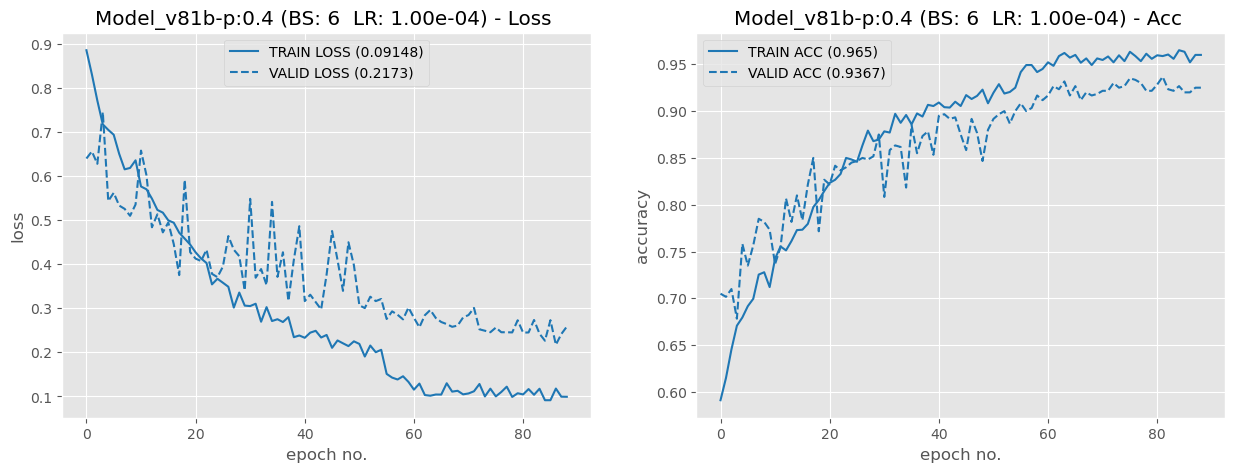

In [57]:
plot_loss_accuracy(train_loss=[metrics.train_loss[1:]], val_loss=[metrics.val_loss[1:]], train_acc=[metrics.train_acc[1:]], val_acc=[metrics.val_acc[1:]], trn_config=train_config)

In [ ]:
# plot_loss_accuracy(train_loss=[metrics.train_loss[1:]], val_loss=[metrics.val_loss[1:]], train_acc=[metrics.train_acc[1:]], val_acc=[metrics.val_acc[1:]], trn_config=train_config)

## <font style="color:blue">4.10. Loss and Accuracy Plot</font>

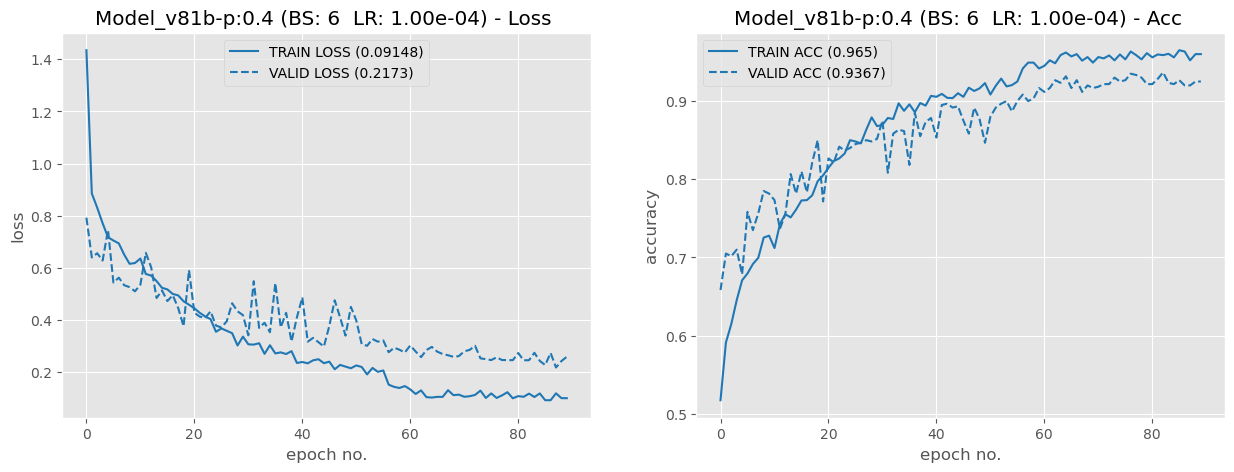

In [60]:
plot_loss_accuracy(train_loss=[metrics.train_loss], 
                   val_loss=[metrics.val_loss], 
                   train_acc=[metrics.train_acc], 
                   val_acc=[metrics.val_acc], 
                   colors=['blue'], 
                   loss_legend_loc='upper center', 
                   acc_legend_loc='upper left',
                   trn_config=train_config)

# <font style="color:blue">Step 5. Sample Prediction</font><a name="step5"></a>

Show some sample predictions.

## <font style="color:blue">5.3. Load Model and Run Inference</font>

In [ ]:
try:
    del model
    print('model')
    del metrics
    print('metrics')
    del optimizer, scheduler
    print('optimizer, scheduler')
    del train_config, sys_config
    print('train_config, sys_config')
    del train_loader, test_loader
    print('train_loader, test_loader')
except Exception as e:
    print(e)
    pass

In [10]:
MODEL_NAME = "Model_v81b"
BATCH_SIZE = 6
LEARNING_RATE = 1.0e-04
DROPOUT_RATE = 0.4
EPOCHS = 90
SUBSET_SIZE = 1.0
print('done')


gc.collect()
torch.cuda.empty_cache()
MODEL = globals()[MODEL_NAME]
model = MODEL(p=DROPOUT_RATE)

done


8

In [ ]:
model = load_model(model, model_dir='models', model_file_name='Model_v81b_BS_006_LR_1.0e-04_p0.4_n_bestacc.pt')
# model = load_model(model, model_dir='models', model_file_name='Model_v81b_BS_006_LR_1.0e-04_p0.4_n_bestloss.pt')
print(model)

In [13]:
train_config = TrainingConfiguration()
test_data_path = os.path.join(train_config.data_root, 'validation')
train_data_path = os.path.join(train_config.data_root, 'training')

mean, std = get_mean_std(train_data_path)

 SubsetSize: 1.000000   Dataset size: 2400


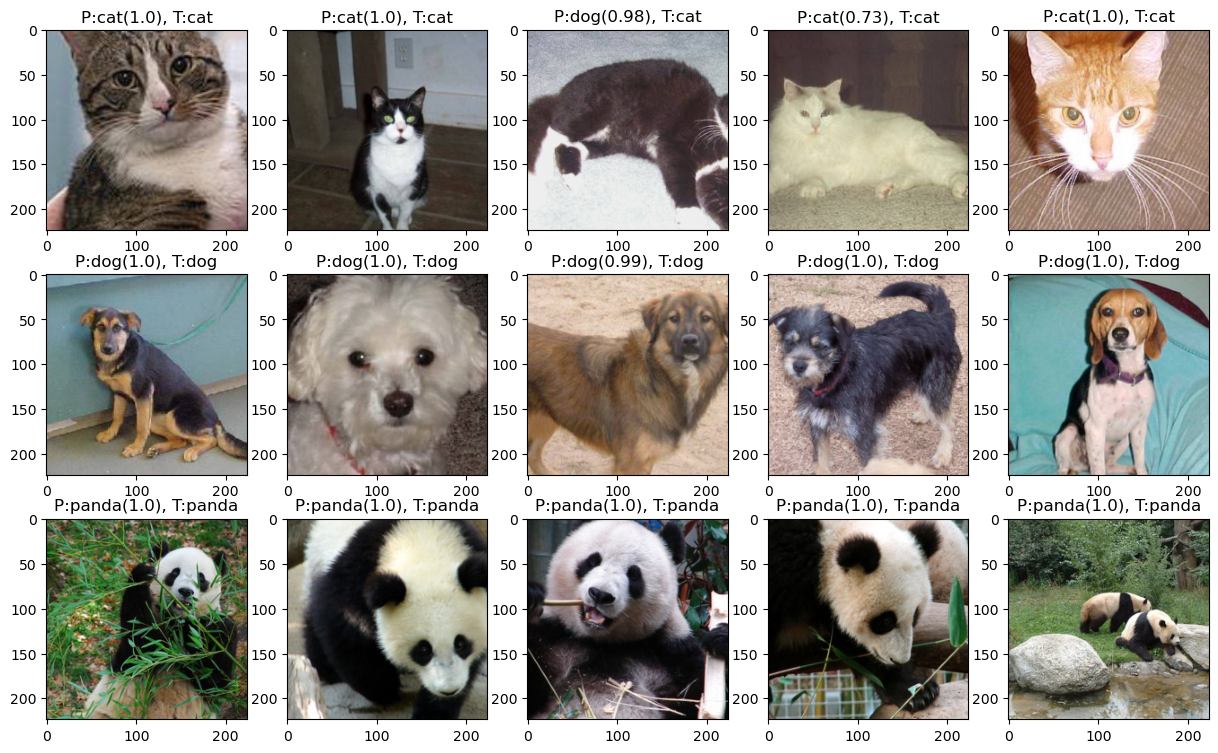

In [14]:
get_sample_prediction(model, test_data_path, mean, std)

# <font style="color:red">Step 6. Display Confusion Matrix [10 Points]</font><a name="step6"></a>

Display the confusion matrix for the above problem(Refer to the earlier lectures on Performance Metrics).


The output should resemble this:

<img src='https://www.learnopencv.com/wp-content/uploads/2020/02/c3_w5_sample_confusion_matrix.png' width=600>


In [15]:
# YOUR CODE HERE

In [30]:
_, test_loader = get_data(batch_size=30,
                          data_root='./cat-dog-panda',
                          num_workers=2,
                          data_augmentation=True,
                          subset_size=1.0
                         )

 SubsetSize: 1.000000   Dataset size: 2400
 SubsetSize: 1.000000   Dataset size: 600


In [ ]:
if torch.cuda.is_available():
    device = "cuda"
    num_workers = 8
else:
    device = "cpu"
    num_workers = 2

# It is important to do model.eval() before prediction
_ = model.eval()
# Send model to cpu/cuda according to your system configuration
_ = model.to(device)

In [18]:
y_true = np.ndarray(0)
y_pred = np.ndarray(0)
y_prob = np.ndarray(0)

for batch_id, (data, target) in enumerate(test_loader,1):
    pred, prob = prediction(model, device, batch_input=data.to(train_config.device))
    print(f" batch_id: {batch_id}")
    y_pred = np.concat((y_pred, pred), axis =0)
    y_prob = np.concat((y_prob, prob), axis =0)
    y_true = np.concat((y_true, target.cpu().numpy()))

 batch_id: 1
 batch_id: 2
 batch_id: 3
 batch_id: 4
 batch_id: 5
 batch_id: 6
 batch_id: 7
 batch_id: 8
 batch_id: 9
 batch_id: 10
 batch_id: 11
 batch_id: 12
 batch_id: 13
 batch_id: 14
 batch_id: 15


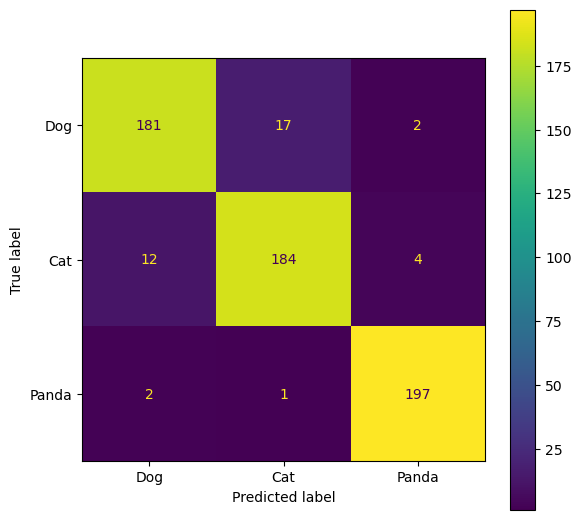

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6.5,6.5))
ConfusionMatrixDisplay.from_predictions(y_true=y_true, y_pred=y_pred, display_labels=['Dog', 'Cat', 'Panda'],ax=ax)

In [31]:
try:
    del model
    print('model')
except Exception as e:
    print(e)
    pass

MODEL_NAME = "Model_v81b"
DROPOUT_RATE = 0.4
gc.collect()
torch.cuda.empty_cache()
MODEL = globals()[MODEL_NAME]
model = MODEL(p=DROPOUT_RATE)
    
model = load_model(model, model_dir='models', model_file_name='Model_v81b_BS_006_LR_1.0e-04_p0.4_n_bestloss.pt')
if torch.cuda.is_available():
    device = "cuda"
    num_workers = 8
else:
    device = "cpu"
    num_workers = 2

# It is important to do model.eval() before prediction
_ = model.eval()
# Send model to cpu/cuda according to your system configuration
_ = model.to(device)

model


3586

In [32]:
y_true = np.ndarray(0)
y_pred = np.ndarray(0)
y_prob = np.ndarray(0)

for batch_id, (data, target) in enumerate(test_loader,1):
    pred, prob = prediction(model, device, batch_input=data.to(train_config.device))
    print(f" batch_id: {batch_id}")
    y_pred = np.concat((y_pred, pred), axis =0)
    y_prob = np.concat((y_prob, prob), axis =0)
    y_true = np.concat((y_true, target.cpu().numpy()))

 batch_id: 1
 batch_id: 2
 batch_id: 3
 batch_id: 4
 batch_id: 5
 batch_id: 6
 batch_id: 7
 batch_id: 8
 batch_id: 9
 batch_id: 10
 batch_id: 11
 batch_id: 12
 batch_id: 13
 batch_id: 14
 batch_id: 15
 batch_id: 16
 batch_id: 17
 batch_id: 18
 batch_id: 19
 batch_id: 20


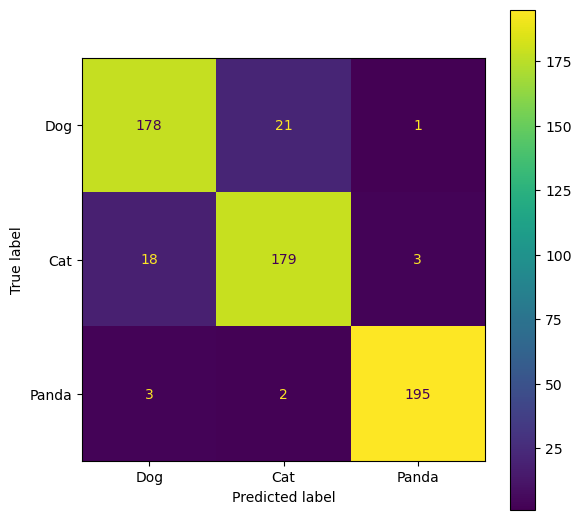

In [33]:
fig, ax = plt.subplots(figsize=(6.5,6.5))
ConfusionMatrixDisplay.from_predictions(y_true=y_true, y_pred=y_pred, display_labels=['Dog', 'Cat', 'Panda'],ax=ax)

Upon completing the assignment,  <font style="color:red">pload the 2 notebooks and the models folder on the portal for feedback.</font>